C:\Users\floxo\AppData\Local\Temp\ipykernel_33360\3080875231.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='W1_W2', data=df, palette='viridis')


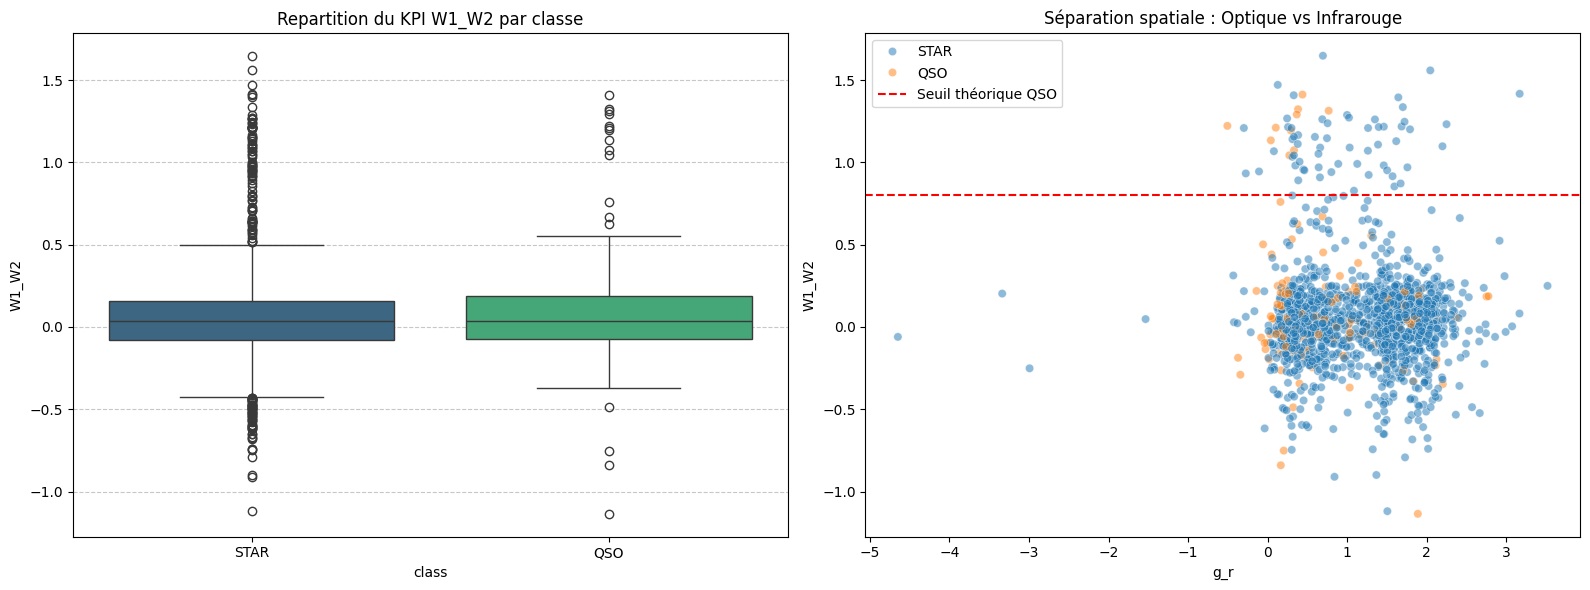

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

df = pd.read_csv("dataset_final_spatial.csv")
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.boxplot(x='class', y='W1_W2', data=df, palette='viridis')
plt.title("Repartition du KPI W1_W2 par classe")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.subplot(1,2,2)
df['g_r'] = df['g'] - df['r']
sns.scatterplot(x='g_r', y='W1_W2', hue='class', data=df, alpha=0.5)
plt.title("Séparation spatiale : Optique vs Infrarouge")
plt.axhline(0.8, color='red', linestyle='--', label='Seuil théorique QSO')
plt.legend()
plt.tight_layout()
plt.show()

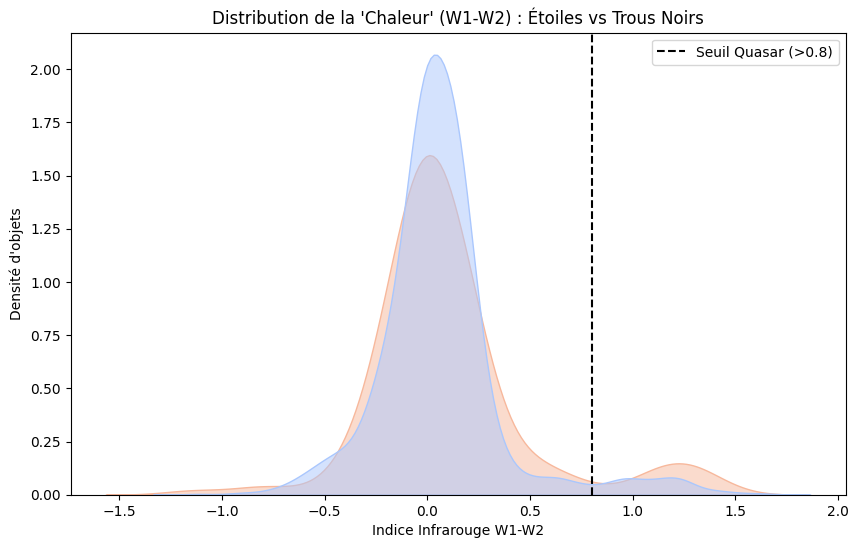

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# On trace la "montagne" de densité pour chaque classe
sns.kdeplot(data=df, x='W1_W2', hue='class', fill=True, common_norm=False, palette='coolwarm', alpha=0.5)

# On trace la ligne de démarcation théorique
plt.axvline(0.8, color='black', linestyle='--', label='Seuil Quasar (>0.8)')

plt.title("Distribution de la 'Chaleur' (W1-W2) : Étoiles vs Trous Noirs")
plt.xlabel("Indice Infrarouge W1-W2")
plt.ylabel("Densité d'objets")
plt.legend()
plt.show()

In [4]:
import pandas as pd
df = pd.read_csv('dataset_final_spatial.csv')
resultat = df[df['class'] == 'QSO'][['class', 'W1_W2']].head(50)
print(resultat)

    class     W1_W2
1     QSO -0.022000
8     QSO -0.263001
9     QSO -0.029000
18    QSO  0.453000
22    QSO  1.194000
26    QSO  1.412001
28    QSO  0.035001
31    QSO  0.057000
32    QSO -0.005000
35    QSO -0.055000
44    QSO  0.036000
46    QSO  0.025002
58    QSO  0.191000
64    QSO  1.211000
65    QSO  0.219000
66    QSO  0.555000
69    QSO -0.123000
71    QSO  0.189000
79    QSO -0.245000
80    QSO -0.132999
81    QSO -0.343000
83    QSO -0.017000
89    QSO  1.043000
92    QSO  1.323000
93    QSO  0.441000
94    QSO -0.045000
95    QSO  1.134000
96    QSO  0.532999
97    QSO -0.187000
105   QSO -0.070000
108   QSO -0.000999
109   QSO -0.002000
112   QSO  0.038000
113   QSO -0.108000
117   QSO -0.136999
121   QSO  0.069000
149   QSO  0.011000
162   QSO -0.030000
172   QSO -0.233001
173   QSO -0.052000
174   QSO  0.125000
180   QSO  0.760000
183   QSO -0.076000
188   QSO  0.244000
189   QSO -0.064999
191   QSO -0.071000
194   QSO -0.167000
200   QSO -0.182999
201   QSO  0.625000


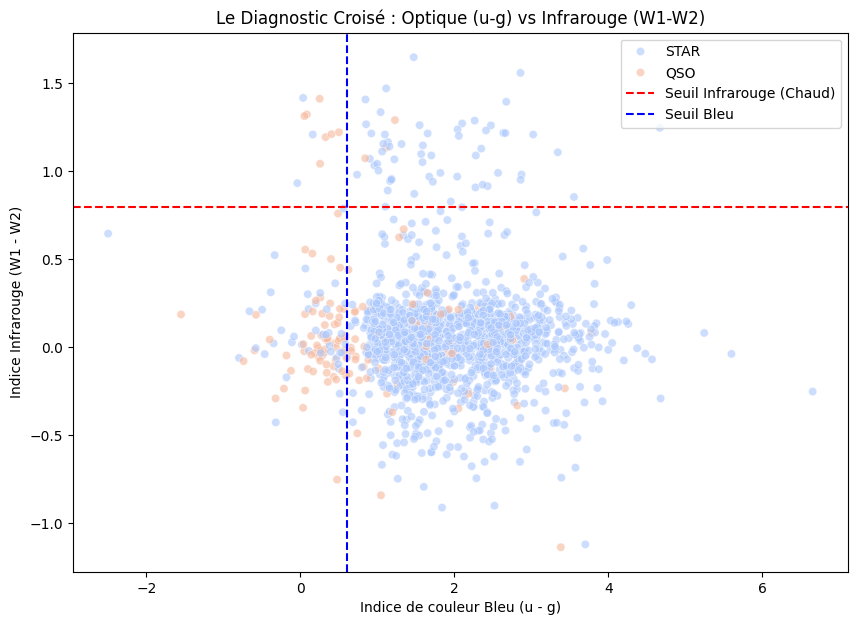

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# On crée l'indice de couleur bleu (U - G)
# Plus cet indice est petit/négatif, plus l'objet est "Bleu"
df['u_g'] = df['u'] - df['g']

plt.figure(figsize=(10, 7))

# On trace le nuage de points
sns.scatterplot(data=df, x='u_g', y='W1_W2', hue='class', alpha=0.6, palette='coolwarm')

# On trace les zones de décision
plt.axhline(0.8, color='red', linestyle='--', label='Seuil Infrarouge (Chaud)')
plt.axvline(0.6, color='blue', linestyle='--', label='Seuil Bleu')

plt.title("Le Diagnostic Croisé : Optique (u-g) vs Infrarouge (W1-W2)")
plt.xlabel("Indice de couleur Bleu (u - g)")
plt.ylabel("Indice Infrarouge (W1 - W2)")
plt.legend()
plt.show()

In [6]:
import pandas as pd

# 1. Charger le dataset
df = pd.read_csv("dataset_final_spatial.csv")

# 2. Afficher le compte des NaN par colonne pour avoir une vue d'ensemble
print("--- Nombre de valeurs manquantes par colonne ---")
print(df.isnull().sum())

# 3. Isoler les lignes qui ont des NaN dans les colonnes de CALCUL (Features)
# On crée une liste des colonnes nécessaires pour le modèle
cols_features = ['u', 'g', 'r', 'i', 'z', 'W1mag', 'W2mag', 'W1_W2', 'u_g']

# On affiche les lignes où au moins une de ces colonnes est vide
nan_features = df[df[cols_features].isnull().any(axis=1)]

print(f"\n--- Lignes avec données manquantes ({len(nan_features)} lignes) ---")
print(nan_features[cols_features + ['class']].head(10))

# 4. Isoler les lignes qui n'ont pas de CLASSE (Tes futurs sujets de test)
df_inconnus = df[df['class'].isnull()]
print(f"\n--- Objets sans classe (À prédire plus tard) : {len(df_inconnus)} lignes ---")

--- Nombre de valeurs manquantes par colonne ---
objid         0
ra            0
dec           0
u             0
g             0
r             0
i             0
z             0
class         0
redshift      0
_q          408
W1mag       408
W2mag       408
W3mag       408
W4mag       408
W1_W2       408
dtype: int64


KeyError: "['u_g'] not in index"

In [7]:
import pandas as pd

df = pd.read_csv("dataset_final_spatial.csv")

# --- ÉTAPE CRUCIALE : On crée la colonne manquante d'abord ---
df['u_g'] = df['u'] - df['g']

# Liste des colonnes nécessaires pour le futur modèle
cols_features = ['u', 'g', 'r', 'i', 'z', 'W1mag', 'W2mag', 'W1_W2', 'u_g']

# On isole les lignes avec des NaN dans ces colonnes
nan_features = df[df[cols_features].isnull().any(axis=1)]

print(f"🔍 Objets SDSS sans correspondance WISE : {len(nan_features)}")

🔍 Objets SDSS sans correspondance WISE : 408


In [8]:
# On ne garde que les lignes où TOUTES les colonnes de features sont remplies
df_ml = df.dropna(subset=cols_features).copy()

print(f"✅ Dataset prêt pour le ML : {len(df_ml)} lignes.")
print(f"📊 Répartition des classes :\n{df_ml['class'].value_counts()}")

# Sauvegarde de cette version propre
df_ml.to_csv("dataset_ready_for_ml.csv", index=False)

✅ Dataset prêt pour le ML : 1592 lignes.
📊 Répartition des classes :
class
STAR    1446
QSO      146
Name: count, dtype: int64
